In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#df=pd.read_csv('/content/raw_data.csv')

In [3]:
df=pd.read_csv('/content/subset_50k+.csv')

In [4]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,55554.000000,5.555400e+04,5.555400e+04,5.555400e+04,5.555400e+04,5.555400e+04,55554.000000,55554.0
mean,7.608381,1.597524e+05,7.212832e+05,7.352591e+05,8.408566e+05,1.171781e+06,0.001800,0.0
std,2.005491,3.293745e+05,2.164072e+06,2.201647e+06,2.412827e+06,2.900258e+06,0.042389,0.0
min,1.000000,6.300000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
25%,7.000000,8.096545e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
50%,8.000000,3.604783e+04,1.746500e+04,0.000000e+00,5.039000e+03,1.542800e+03,0.000000,0.0
75%,9.000000,1.916204e+05,1.373876e+05,1.506953e+05,4.722007e+05,8.963237e+05,0.000000,0.0
max,9.000000,1.000000e+07,2.854724e+07,2.861740e+07,3.017978e+07,3.197699e+07,1.000000,0.0


In [5]:
df.shape

(55554, 11)

# **55554 rows and 11 columns**

In [6]:
df.head(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55554 entries, 0 to 55553
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            55554 non-null  int64  
 1   type            55554 non-null  object 
 2   amount          55554 non-null  float64
 3   nameOrig        55554 non-null  object 
 4   oldbalanceOrg   55554 non-null  float64
 5   newbalanceOrig  55554 non-null  float64
 6   nameDest        55554 non-null  object 
 7   oldbalanceDest  55554 non-null  float64
 8   newbalanceDest  55554 non-null  float64
 9   isFraud         55554 non-null  int64  
 10  isFlaggedFraud  55554 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 4.7+ MB


In [8]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


# **No null values**

In [9]:
df.duplicated().sum()

np.int64(0)

# **No duplicate values present**

In [10]:
df['type'].value_counts()

,count
type,
PAYMENT,23993
CASH_OUT,15526
CASH_IN,10111
TRANSFER,5230
DEBIT,694


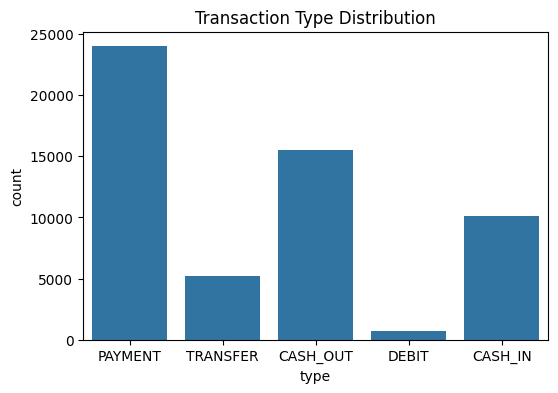

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='type')
plt.title("Transaction Type Distribution")
plt.show()

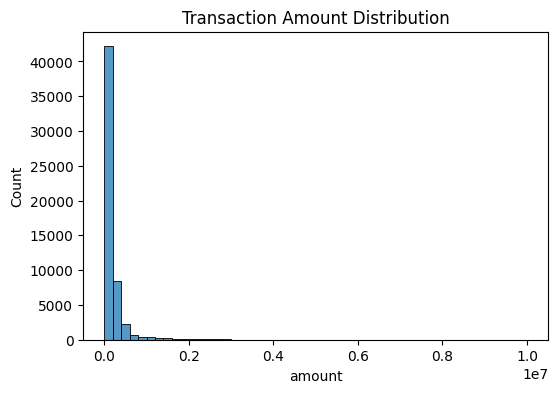

In [12]:
plt.figure(figsize=(6,4))
sns.histplot(df['amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

In [13]:
df['isFraud'].value_counts()

,count
isFraud,
0,55454
1,100


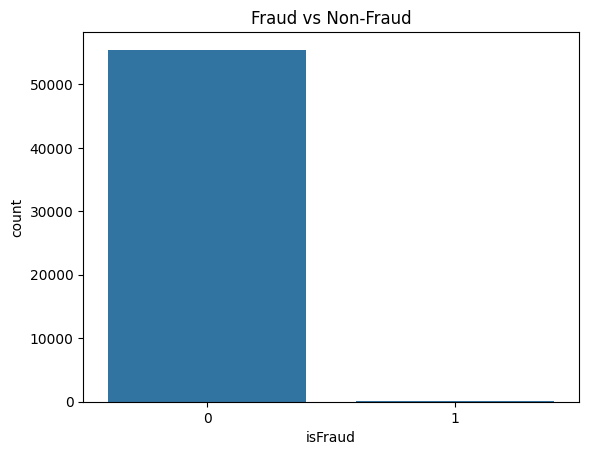

In [14]:
sns.countplot(data=df, x='isFraud')
plt.title("Fraud vs Non-Fraud")
plt.show()

In [15]:
fraud_by_type = df.groupby('type')['isFraud'].sum()
fraud_by_type

,isFraud
type,
CASH_IN,0
CASH_OUT,51
DEBIT,0
PAYMENT,0
TRANSFER,49


# **51 frauds with type 'Cash_Out' and 49 with 'Transfer'**

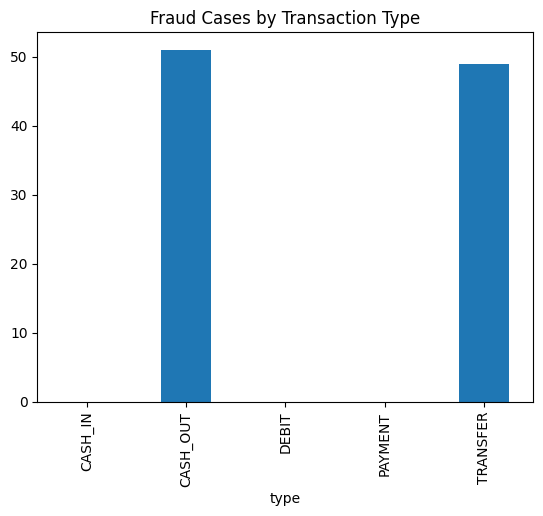

In [16]:
fraud_by_type.plot(kind='bar')
plt.title("Fraud Cases by Transaction Type")
plt.show()

In [17]:
avg_amount = df['amount'].mean()

df['value_category'] = df['amount'].apply(
    lambda x: 'high' if x > avg_amount else 'low'
)

df.groupby('value_category')['isFraud'].agg(['count','sum'])

,count,sum
value_category,,
high,16241,33
low,39313,67


In [18]:
avg_amount = df['amount'].mean()

df['value_category'] = df['amount'].apply(
    lambda x: 'high' if x > avg_amount else 'low'
)

value_analysis = df.groupby('value_category')['isFraud'].agg(['count', 'sum']).reset_index()

# rename columns for clarity
value_analysis.columns = ['value_category', 'total_transactions', 'fraud_cases']

# calculate fraud probability (%)
value_analysis['fraud_probability (%)'] = round(
    (value_analysis['fraud_cases'] / value_analysis['total_transactions']) * 100, 2
)

value_analysis

,value_category,total_transactions,fraud_cases,fraud_probability (%)
0,high,16241,33,0.20
1,low,39313,67,0.17


# **0.20% fraud probability with 'high' value and 0.17% fraud probability with 'low' value**


---



